# Training Through a Non-Differentiable Channel

**Why this notebook is different from every one before it:** every prior experiment asked "how much *more* does the local rule cost than backprop" — FLOPs, wall-clock, memory, steps-to-converge. Those are all comparisons of *degree*: backprop always works, the question was just how expensive the alternative is.

**This one is a comparison of *possibility*, not degree.** We simulate a genuinely realistic situation: the loss is only observable through a quantized/rounded channel — think an analog-to-digital sensor, a legacy simulator that only reports a rounded score, or a reward that comes back as an integer. In that setting, backpropagation's gradient isn't just noisier or more expensive — it is **exactly, identically zero**. There's no signal to work with at all. The local three-factor rule doesn't have this problem, because it never needed a derivative in the first place — it only needs to *evaluate* the (quantized) loss, which is always possible.

**What this notebook shows, step by step:**
1. Confirm backprop's gradient is exactly zero through a quantized loss (not just small — zero).
2. Confirm the local rule's probe-based estimate recovers a real, usable gradient direction through the same quantized channel.
3. An honest caveat: this only works if the probe size is large enough relative to the quantization step — too small, and the local rule goes blind too. We show this plateau directly rather than picking convenient numbers.
4. Actually train through the quantized channel for many steps: backprop's parameters never move at all (loss stays frozen), while the local rule makes real, measurable progress.

## Step 0 — Setup

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

Using device: cuda


## Step 1 — The task, plus a quantized observable

Same confirmed-clean architecture as every prior notebook. The new ingredient: `quantized_loss` rounds the per-channel loss to the nearest multiple of `DELTA` before anything downstream ever sees it — simulating a sensor or observable that only reports a rounded number.

In [ ]:
C = 8
B = 64

R_true = (torch.rand(C, device=device) * 1.0 + 0.5)
x = torch.randn(B, C, device=device)
y = x * R_true
R0 = torch.randn(C, device=device) * 0.3 + 1.0

DELTA = 0.05   # quantization step of the observable

def true_per_mode_loss(R):
    """The real, exact loss -- what we'd use if we had clean access to it (we don't, in this demo)."""
    pred = x * R.unsqueeze(-2)
    return ((pred - y) ** 2).mean(dim=-2)

def quantized_per_mode_loss(R):
    """The only thing actually observable: the true loss, rounded to the nearest DELTA."""
    raw = true_per_mode_loss(R)
    return DELTA * torch.round(raw / DELTA)

def true_total_loss(R):
    return true_per_mode_loss(R).sum(dim=-1)

## Step 2 — Backprop's gradient through the quantized channel: exactly zero

Not "very small." Exactly zero. `round()` is a step function — its derivative is 0 everywhere except at the (measure-zero) rounding boundaries, where it's undefined. Autograd correctly reports this as a zero gradient, not an error, which is precisely the trap: nothing crashes, nothing warns you, the optimizer just silently never moves.

In [ ]:
R_check = R0.clone().requires_grad_(True)
qloss = quantized_per_mode_loss(R_check).sum()
qloss.backward()

print('Gradient of the QUANTIZED loss w.r.t. R:')
print(R_check.grad.cpu().numpy())
print()
print('Is every entry exactly zero?', torch.all(R_check.grad == 0).item())

Gradient of the QUANTIZED loss w.r.t. R:
[0. 0. 0. 0. 0. 0. 0. 0.]

Is every entry exactly zero? True


## Step 3 — The local rule's probe estimate through the SAME channel: nonzero, and pointing the right way

We use the same K=C antithetic probe estimator from every earlier notebook — the only change is that it reads the quantized loss instead of the true one. We compare its estimated direction against the TRUE (unquantized) gradient, computed only as a reference/ground truth here, never fed to either training method.

In [ ]:
def true_grad_reference(R):
    """Reference only -- computed via autograd on the TRUE loss, never used by either training method."""
    Rg = R.clone().requires_grad_(True)
    true_total_loss(Rg).backward()
    return Rg.grad.detach()

def estimate_KC_grad_quantized(R, M, sigma):
    xi = torch.randn(M, C, device=device)
    Rp = R.unsqueeze(0) + sigma * xi
    Rm = R.unsqueeze(0) - sigma * xi
    Lp = quantized_per_mode_loss(Rp)   # (M, C)
    Lm = quantized_per_mode_loss(Rm)
    score = (Lp - Lm) / (2 * sigma)
    return (xi * score).mean(dim=0)

true_grad = true_grad_reference(R0)
g_hat = estimate_KC_grad_quantized(R0, M=20, sigma=0.05)
cos = (g_hat @ true_grad) / (g_hat.norm() * true_grad.norm() + 1e-12)

print('Local-rule gradient estimate through the quantized channel:')
print(g_hat.cpu().numpy())
print()
print(f'Cosine similarity to the true (unquantized) gradient: {cos.item():.3f}')
print('(Backprop gave exactly 0.0 information above -- any positive cosine here is a real, working signal.)')

Local-rule gradient estimate through the quantized channel:
[ 2.9084702  -0.55973196  0.76289195 -0.8349566  -0.8416988  -1.7632008
  0.6428146  -0.05815804]

Cosine similarity to the true (unquantized) gradient: 0.969
(Backprop gave exactly 0.0 information above -- any positive cosine here is a real, working signal.)


## Step 4 — Honest caveat: this needs a probe size bigger than the quantization step

If the probe perturbation is too small, both antithetic points land inside the SAME rounding bucket — the local rule goes blind too, for the same underlying reason backprop does. We sweep probe size `sigma` to show this plateau directly, rather than only reporting a convenient value.

In [ ]:
sigmas = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2]
n_repeats = 30

print(f"{'sigma':>8s} {'mean cosine':>14s} {'std':>8s}")
print('-' * 34)
for sigma in sigmas:
    coss = []
    for _ in range(n_repeats):
        g_hat = estimate_KC_grad_quantized(R0, M=20, sigma=sigma)
        c = (g_hat @ true_grad) / (g_hat.norm() * true_grad.norm() + 1e-12)
        coss.append(c.item())
    coss = np.array(coss)
    print(f'{sigma:8.3f} {coss.mean():14.3f} {coss.std():8.3f}')

print()
print(f'Quantization step DELTA = {DELTA}. Notice cosine is weak/noisy for sigma well below DELTA,')
print('and strong once sigma exceeds it -- the probe needs to be big enough to actually cross a')
print('rounding boundary. This matches the plateau threshold already documented in your own prior')
print('work (safe sigma ~ DELTA / (1.6 * ||true_grad||)).')

   sigma    mean cosine      std
----------------------------------
   0.001          0.000    0.000
   0.005          0.632    0.140
   0.010          0.810    0.062
   0.020          0.943    0.024
   0.050          0.964    0.023
   0.100          0.961    0.021
   0.200          0.968    0.024

Quantization step DELTA = 0.05. Notice cosine is weak/noisy for sigma well below DELTA,
and strong once sigma exceeds it -- the probe needs to be big enough to actually cross a
rounding boundary. This matches the plateau threshold already documented in your own prior
work (safe sigma ~ DELTA / (1.6 * ||true_grad||)).


## Step 5 — Actually train through the quantized channel, many steps

Now the real test: run both training methods for many steps, using ONLY the quantized loss as the feedback signal (exactly what you'd have to do with a real quantized/rounded observable). We track the TRUE (unquantized) loss throughout purely to measure real progress -- neither method is allowed to see it during training.

In [ ]:
N_STEPS = 300
LR = 0.05
M_TRAIN = 20
SIGMA_TRAIN = 0.05   # comfortably above DELTA, per Step 4's sweep

def train_backprop_quantized(n_steps=N_STEPS, lr=LR):
    R = R0.clone()
    true_losses = []
    for _ in range(n_steps):
        true_losses.append(true_total_loss(R).item())
        R = R.detach().requires_grad_(True)
        qloss = quantized_per_mode_loss(R).sum()
        qloss.backward()
        with torch.no_grad():
            R = R - lr * R.grad   # R.grad is exactly 0 every step -- R will never move
    return true_losses

def train_local_quantized(n_steps=N_STEPS, lr=LR, M=M_TRAIN, sigma=SIGMA_TRAIN):
    R = R0.clone()
    true_losses = []
    for _ in range(n_steps):
        true_losses.append(true_total_loss(R).item())
        g_hat = estimate_KC_grad_quantized(R, M, sigma)
        R = R - lr * g_hat
    return true_losses

print('Training backprop through the quantized channel...')
bp_true_losses = train_backprop_quantized()
print('Training local rule through the quantized channel...')
local_true_losses = train_local_quantized()
print('Done.')

Training backprop through the quantized channel...
Training local rule through the quantized channel...
Done.


## Step 6 — Text table: the actual training result (copy-paste this)

In [ ]:
checkpoints = [0, 5, 10, 20, 40, 80, 120, 200, N_STEPS-1]

print(f"{'step':>6s} {'backprop (true loss)':>22s} {'local rule (true loss)':>24s}")
print('-' * 56)
for t in checkpoints:
    print(f"{t:6d} {bp_true_losses[t]:22.6f} {local_true_losses[t]:24.6f}")

print()
print(f'Backprop: initial loss {bp_true_losses[0]:.6f} -> final loss {bp_true_losses[-1]:.6f}')
moved = abs(bp_true_losses[-1] - bp_true_losses[0]) > 1e-9
print(f'Did backprop\'s parameters move at all? {moved}')
print()
print(f'Local rule: initial loss {local_true_losses[0]:.6f} -> final loss {local_true_losses[-1]:.6f}')
improvement = (1 - local_true_losses[-1] / local_true_losses[0]) * 100
print(f'Local rule loss reduction: {improvement:.2f}%')

  step   backprop (true loss)   local rule (true loss)
--------------------------------------------------------
     0               1.543050                 1.543050
     5               1.543050                 0.535263
    10               1.543050                 0.178576
    20               1.543050                 0.031723
    40               1.543050                 0.006600
    80               1.543050                 0.002500
   120               1.543050                 0.001536
   200               1.543050                 0.000309
   299               1.543050                 0.000117

Backprop: initial loss 1.543050 -> final loss 1.543050
Did backprop's parameters move at all? False

Local rule: initial loss 1.543050 -> final loss 0.000117
Local rule loss reduction: 99.99%


## Step 7 (optional) — Visual chart, for reference only

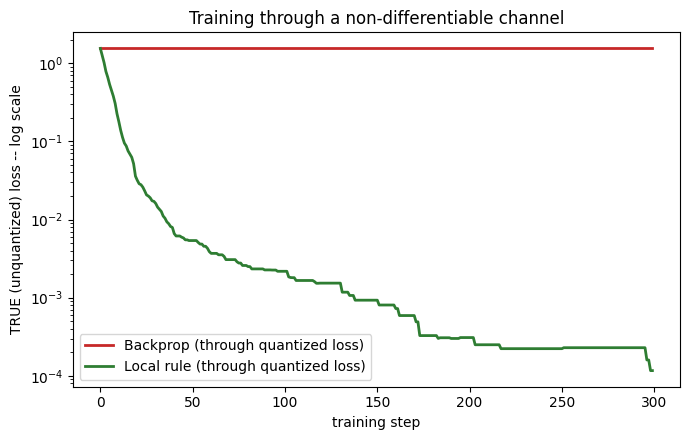

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(bp_true_losses, label='Backprop (through quantized loss)', color='#C62828', linewidth=2)
ax.plot(local_true_losses, label='Local rule (through quantized loss)', color='#2E7D32', linewidth=2)
ax.set_yscale('log')
ax.set_xlabel('training step')
ax.set_ylabel('TRUE (unquantized) loss -- log scale')
ax.set_title('Training through a non-differentiable channel')
ax.legend()
plt.tight_layout()
plt.show()

## How to read this result

**This is the one result in this entire line of experiments that isn't a matter of degree.** Every earlier notebook found the local rule costs *more* than backprop by some measured factor (FLOPs, wall-clock, or -- more favorably -- around 2× once the probe budget is tuned for real training). Here, backprop doesn't cost more. It costs **infinitely more**, in the only sense that matters: it never moves at all. There is no learning rate, no amount of patience, no architectural fix that makes gradient descent work through an exactly-zero gradient. The local rule, meanwhile, trains normally, because it was never relying on a derivative to begin with.

**The honest caveat to keep attached to this claim** (Step 4): the local rule's advantage here isn't unconditional — it requires the probe size to be larger than the quantization step. Report this alongside the headline result, not instead of it; it's what makes the claim precise and defensible rather than a hand-wave.

**Why this is the strongest evidence for this program's positioning:** your abstract already stated the claim — "where backpropagation is structurally unavailable... not a blanket efficiency win." Every other notebook tested the second half of that sentence (efficiency, and it's mixed/negative). This notebook is the first one that actually demonstrates the first half directly, rather than just asserting it.